### Lösung linearer Gleichungssysteme

Lineare Gleichungssysteme $\mathbf{A}\mathbf{x}=\mathbf{b}$ treten bereits ab der 6. Klasse auf, auch wenn sie nicht in der standardisierten Form gegeben sind, sondern in der "ausgeschriebenen Form": 

$$\begin{pmatrix} a_{1,1} x_1 + a_{1,2} x_2 + a_{1,3} x_3 &=& b_1 \\
 a_{2,1} x_1 + a_{2,2} x_2 + a_{2,3} x_3 &=& b_2 \\
 a_{3,1} x_1 + a_{3,2} x_2 + a_{3,3} x_3 &=& b_3 
\end{pmatrix}$$

Im Beispiel verwenden wir konkrete Zahlwerte:

$$\begin{pmatrix} x_1 &+& 2 x_2 &+& 3 x_3 &=& 10 \\
 4 x_1 &+& x_2 &+& 6 x_3 &=& 11\\
 7 x_1 &+&  x_2 &+& 9 x_3 &=& 12
\end{pmatrix}$$


Das Python-Paket **numpy** kann verwendet werden, um lineare Gleichungssysteme zu lösen. Dazu definieren wir zuerst die Matrix:


In [9]:
import numpy as np

A = np.array([ [1, 2, 3], [4, 1, 6], [7, 1, 9] ])
print(A)  # gibt die Matrix aus



[[1 2 3]
 [4 1 6]
 [7 1 9]]


In [10]:
# Die Matrix wird in numpy offenbar als Menge von "gestapelten" Zeilenvektoren definiert.
# Das nennt man "row-major", der Zeilenindex hat Vorrang vor dem Spaltenindex,
# und im Moment ist das nur relevant, um zu verstehen, wie die konkreten Zahlwerte 
# in Python eingegeben werden.

import numpy as np

A = np.array([ [1, 2, 3], [4, 1, 6], [7, 1, 9] ])

# Für ein lineares Gleichungssystem benötigen wir noch eine rechte Seite, 
# als Vektor wird dies genau so definiert wie die Matrix:
b = np.array( [10, 11, 12])

# Nun lösen wir das lineare Gleichungssystem:
x = np.linalg.solve(A,b)

# Wir geben das Ergebnis aus:
print("Ergebnis:")
print(x)

# Wir überzeugen uns von der Korrektheit des Ergebnisses, indem wir Ax-b ausrechnen
# lassen. Wenn x die Lösung ist, sollte das Ergebnis der Nullvektor sein.
# Die Syntax für das Matrix-Vektor Produkt erklären wir in einer späteren Einheit
print("Probe:")
print(A.dot(x)-b)



[-4.50000000e+00  4.78249918e-15  4.83333333e+00]
Probe:
[ 0.00000000e+00 -3.55271368e-15 -3.55271368e-15]


Die Zahlen werden in sogenannter **wissenschaftlicher Notation** ausgegeben, bspw. ist das Ergebnis für $x_1$ zu lesen als $-4.5\cdot 10^0$, und da $10^0$ gerade $1$ ist, ist das Ergebnis die Zahl $-4.5$. 

Irritierend sind die Großenordnungen von zwei Zahlen, $10^{-16}$ und $10^{-15}$. Wir glaube an dieser Stelle, dass bspw. die Zahl $0.000000000000000956499837$ im Rahmen der Rechengenauigkeit des Computers hier faktisch eine Null ist, und kommen in einer späteren Einheit darauf zurück.



### Lösung quadratischer Gleichungen mit der pq-Mitternachtsformel

Oft sind wir nicht an konkreten Zahlwerten interessiert, sondern daran, "mit Buchstaben zu rechnen" und trotzdem "Formeln" soweit wie möglich zusammenzufassen. Das pragmatische Ziel für den Unterricht (oder besser: die Vorbereitung des Unterrichts) besteht darin, diese **symbolische Formelmanipulaton** zu automatisieren. Fortgeschrittene Beispiele sind das Experimentieren mit Substitutionen bei der Integralrechnung, oder die Vereinfachung von Ausdrücken bei der Differentiation. 

In dieser Einführung demonstrieren wir das Python-Paket **sympy** für symbolische Berechnungen dieser Art anhand der automatischen Herleitung der pq-Mitternachts-Lösungsformel für quadratische Gleichungen. Der tatsächliche Funktionsumfang von **numpy** und **sympy** ist Bestandteil späterer Kurseinheiten.



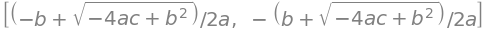

In [12]:
from sympy import *

# Das wird später erklärt, es dient nur der Verbesserung der Lesbarkeit der Ausgabe.
init_printing()

# Hier werden die Symbole definiert, mit denen gerechnet werden soll.
a, b, c, x = symbols('a b c x')   

# Hier passieren drei Dinge gleichzeitig: Zum einen wird aus den Symbolen eine 
# symbolische Gleichung konstruiert, hier das klassische quadratische Polynom. 
# Zweitens wird aus dem Polynom eine Gleichung konstruiert durch Nullsetzen.
# Drittens wird die Gleichung nach dem Symbol x symbolisch aufgelöst durch solve().
solve(Eq(a*x**2 + b*x + c, 0), x) 